# Semantic Bridge Analysis

## A TACC Computational Cookbook

**Developed by:** Texas Advanced Computing Center (TACC)  
**Institution:** The University of Texas at Austin  
**Contact:** [DSO@tacc.utexas.edu](mailto:DSO@tacc.utexas.edu)

---

### What This Cookbook Does

This tutorial demonstrates how to move from qualitative stakeholder narratives to quantitative scientific framing using natural language processing and lightweight machine learning.

By the end of the workflow, you will be able to:
1. discover themes in stakeholder documents
2. extract decision components such as goals, objectives, variables, and constraints
3. map those themes to scientific domains
4. connect plain-language concepts to scientific variables
5. generate outputs that support downstream decision analysis

Typical use cases include environmental planning, climate adaptation, infrastructure decision support, participatory modeling, and interdisciplinary problem framing.

### Prerequisites

- A TACC account and allocation, or another environment prepared from this repository
- Basic familiarity with Jupyter notebooks and Python
- A set of documents that describe a planning or decision problem

Supported inputs include `.txt`, `.json`, `.docx`, `.pdf`, and common image formats for OCR-based extraction.

### Quick Start

1. Run the setup cells to verify the managed environment.
2. Place source documents in `data/subsidence_groundwater_corpus/raw/` or cleaned text in `data/subsidence_groundwater_corpus/cleaned/`.
3. Work through the topic discovery, science mapping, and decision-component extraction steps.
4. Review the generated figures, tables, and summary report in `outputs/`.

### Expected Outputs

- `*_topic_mappings.csv`: topics linked to scientific domains
- `*_components.csv`: extracted decision components
- `*_svo_mappings.csv`: semantic links to scientific variables
- `*_network.html`: interactive science-backbone visualization
- `*_report.md`: summary report for sharing and review

### Customization

- Update `science_backbone` to reflect your domain structure.
- Expand `svo_vocabulary` with variables relevant to your project.
- Adjust `n_topics` to match the size and diversity of your document set.
- Refine the decision-component extraction patterns for your context.

### Learn More

- [TACC Documentation](https://docs.tacc.utexas.edu)
- [TACC Training](https://learn.tacc.utexas.edu)
- [Science Gateways Community Institute](https://sciencegateways.org/)



In [1]:
import os
from pathlib import Path

import pandas as pd
import spacy
from dotenv import load_dotenv

from semantic_bridge.notebook import display as nbutils
from semantic_bridge import api as sbp

nlp = spacy.load('en_core_web_sm')
print('Libraries loaded successfully.')


Libraries loaded successfully.


## Step 2: Prepare Input Data

In this step, you will assemble the document collection, or corpus, that describes the problem you want to analyze.

Typical examples include:
- Interview transcripts
- Meeting notes
- Stakeholder reports
- Grey literature reports
- Community narratives

**Supported formats:**
- `.txt` - Plain text files
- `.json` - JSON with text content (field: `text`, `content`, `body`, or `description`)
- `.docx` - Microsoft Word documents
- `.pdf` - PDFs with extractable text
- `.png` / `.jpg` / `.jpeg` / `.tif` / `.tiff` - Images for OCR extraction

**Corpus sources:**
- Use the local tutorial corpus in `data/subsidence_groundwater_corpus/`
- Or register that corpus as a CKAN dataset and let this notebook download the resources automatically

**Local corpus layout:**
- Put source files in `data/subsidence_groundwater_corpus/raw/`
- Put cleaned text files in `data/subsidence_groundwater_corpus/cleaned/` if you already have them
- The loader will prefer `cleaned/` when both versions exist and otherwise fall back to `raw/`


### Locate the Working Directories

This cell finds the tutorial folder on disk and identifies the local corpus directories the rest of the notebook can use.


In [2]:
tutorial_dir = nbutils.resolve_tutorial_dir()
load_dotenv(tutorial_dir / 'env.sample', override=False)

corpus_dir = sbp.ensure_data_directory(tutorial_dir / 'data' / 'subsidence_groundwater_corpus')
raw_dir = sbp.ensure_data_directory(corpus_dir / 'raw')
cleaned_dir = sbp.ensure_data_directory(corpus_dir / 'cleaned')
local_data_dir = cleaned_dir if any(cleaned_dir.iterdir()) else raw_dir
analysis_data_dir = local_data_dir

CKAN_URL = os.getenv('CKAN_URL', '').strip()
CKAN_API_TOKEN = os.getenv('CKAN_API_TOKEN', '').strip()
CKAN_DATASET_NAME = os.getenv('CKAN_DATASET_NAME', '').strip()

TOPIC_LABELER_MODEL = os.getenv('TOPIC_LABELER_MODEL', '').strip()
TOPIC_LABELER_BASE_URL = os.getenv('OPENAI_BASE_URL', '').strip()
TOPIC_LABELER_API_KEY = os.getenv('OPENAI_API_KEY', '').strip()

MINT_API_BASE_URL = os.getenv('MINT_API_BASE_URL', '').strip()
MINT_USERNAME = os.getenv('MINT_USERNAME', '').strip()
MINT_SVO_PER_PAGE = int(os.getenv('MINT_SVO_PER_PAGE', '200') or '200')
MINT_SVO_MAX_PAGES = int(os.getenv('MINT_SVO_MAX_PAGES', '3') or '3')
MINT_MODEL_PER_PAGE = int(os.getenv('MINT_MODEL_PER_PAGE', '100') or '100')
MINT_MODEL_MAX_PAGES = int(os.getenv('MINT_MODEL_MAX_PAGES', '3') or '3')
MINT_TOPIC_PER_PAGE = int(os.getenv('MINT_TOPIC_PER_PAGE', '100') or '100')
MINT_TOPIC_MAX_PAGES = int(os.getenv('MINT_TOPIC_MAX_PAGES', '3') or '3')


### Optional: Load the Corpus from CKAN

Configuration values such as CKAN URLs, API keys, and external service endpoints are loaded from the tutorial directory `.env` file when present. This keeps the tutorial notebook focused on analysis rather than setup details.

If `CKAN_URL` and `CKAN_DATASET_NAME` are configured, the notebook will fetch the dataset through the CKAN API and cache its resources locally. Otherwise, it will continue using the local tutorial corpus.


In [3]:
if CKAN_URL and CKAN_DATASET_NAME:
    ckan_cache_dir = sbp.ensure_data_directory(corpus_dir / 'ckan_cache')
    ckan_dataset = sbp.fetch_ckan_dataset(CKAN_URL, CKAN_DATASET_NAME)
    downloaded_resources = sbp.sync_ckan_resources_to_directory(
        ckan_dataset,
        ckan_cache_dir,
        base_url=CKAN_URL,

    )
    analysis_data_dir = ckan_cache_dir
    print(f'Loaded {len(downloaded_resources)} CKAN resources from {CKAN_DATASET_NAME}')
else:
    print('Using the local tutorial corpus directories.')

nbutils.print_runtime_paths(tutorial_dir, corpus_dir, raw_dir, cleaned_dir, analysis_data_dir)


Loaded 5 CKAN resources from subsidence-groundwater-semantic-bridge-corpus


**Runtime Paths**
- **Tutorial directory:** `/Users/wmobley/Documents/GitHub/DSO/DSO-Institute-2026/Day-3/Morning`
- **Corpus directory:** `/Users/wmobley/Documents/GitHub/DSO/DSO-Institute-2026/Day-3/Morning/data/subsidence_groundwater_corpus`
- **Raw source directory:** `/Users/wmobley/Documents/GitHub/DSO/DSO-Institute-2026/Day-3/Morning/data/subsidence_groundwater_corpus/raw`
- **Cleaned text directory:** `/Users/wmobley/Documents/GitHub/DSO/DSO-Institute-2026/Day-3/Morning/data/subsidence_groundwater_corpus/cleaned`
- **Active input directory:** `/Users/wmobley/Documents/GitHub/DSO/DSO-Institute-2026/Day-3/Morning/data/subsidence_groundwater_corpus/ckan_cache`

In [4]:
transcripts = sbp.load_documents(analysis_data_dir)
nbutils.print_document_list(transcripts)


invalid pdf header: b'<!-- '
EOF marker not found
invalid pdf header: b'<!-- '
EOF marker not found


Skipping region-h-water-plan-2021.pdf: Stream has ended unexpectedly
Skipping texas-state-water-plan-2022.pdf: Stream has ended unexpectedly


**Loaded Documents:** 3
- `harris-galveston-subsidence-district-regulatory-plan-amended-2021.pdf`
- `texas-tribune-groundwater-pumping-on-gulf-coast-leads-to-subsidence.txt`
- `texas-tribune-groundwater-rights-and-water-crisis.txt`

### Inspect the Input Text

Before modeling anything, it helps to look at a short preview from each document. This gives you a quick sense of writing style, data quality, and whether the right files were loaded.


In [5]:
nbutils.print_document_previews(sbp.preview_documents(transcripts))




### `harris-galveston-subsidence-district-regulatory-plan-amended-2021.pdf`
```text
 
Regulatory Plan 
2013 
 
 
 
 
 
 
 
 
Harris-Galveston  
Subsidence District 
1660 West Bay Area Blvd. 
Friendswood, Texas 77546-2640 
(281) 486-1105 
www.subsidence.org 
 
 
 
Adopted:  January 9,...
```

### `texas-tribune-groundwater-pumping-on-gulf-coast-leads-to-subsidence.txt`
```text

Beneath the Surface
Groundwater Pumping Takes an Unexpected Toll on the Texas Gulf Coast
Unlike the rest of the state, the Texas Gulf Coast has been working for decades to reduce dependency on ground...
```

### `texas-tribune-groundwater-rights-and-water-crisis.txt`
```text

<h1>The one thing Texas won’t do to save its water supply</h1>
<p class="byline">by Jayme Lozano Carver and Yuriko Schumacher, The Texas Tribune <br />May 29, 2025</p>
<p><em><a href="https://www.tex...
```

### Check Corpus Size

This cell reports basic corpus statistics such as document length, word counts, and sentence counts. Use it to confirm that the documents are substantial enough for topic discovery.


In [6]:
stats_df = sbp.build_stats_table(transcripts)

print('✓ Transcript Statistics:\n')
print(stats_df.to_string(index=False))



✓ Transcript Statistics:

                                                                   File  Characters  Words  Sentences
  harris-galveston-subsidence-district-regulatory-plan-amended-2021.pdf       28767   4119        184
texas-tribune-groundwater-pumping-on-gulf-coast-leads-to-subsidence.txt       25152   3750        137
                  texas-tribune-groundwater-rights-and-water-crisis.txt       60955   9087        448


## Step 2: Configure Filler Words

Use this cell to remove transcript fillers or domain-specific words that would otherwise dominate the topic model.

Examples include hesitation words such as `um` and `uh`, or repeated interview artifacts such as speaker labels.


### Define Filler Words to Exclude

Use this cell to remove conversational fillers or repeated artifacts that are not analytically useful. These words will be filtered before topic modeling so they do not dominate the learned themes.


In [7]:
CUSTOM_STOPWORDS = {
    'um',
    'uh',
    'like',
    'you',
    'know',
}

print('Custom filler-word list:')
print(sorted(CUSTOM_STOPWORDS))



Custom filler-word list:
['know', 'like', 'uh', 'um', 'you']


## Step 3: Discover Topics

This step uses topic modeling to identify the main themes in the corpus. The goal is not to produce perfect labels on the first pass, but to surface useful clusters of language that you can interpret, refine, and connect to scientific domains.

**What topic modeling does:**
1. Break text into words and phrases
2. Find terms that co-occur across documents
3. Group those terms into topics
4. Estimate which topics are most associated with each document

**Parameters used in this step:**
- `n_topics` - Number of topic clusters to discover across the corpus
- `max_vocabulary` - Maximum number of terms the model can consider
- `top_words_display` - Number of keywords to show when summarizing each topic

For small tutorial corpora, values around `100` for `max_vocabulary` are usually fine. Larger or more diverse corpora often benefit from higher values.


### Set Topic Parameters

Adjust these values to control how the topic model behaves. This is the main place to tune the level of thematic detail you want from the corpus.


In [8]:
n_topics = 5
max_vocabulary = 200
top_words_display = 12
nbutils.print_topic_parameters(n_topics, max_vocabulary, top_words_display)




**Topic Model Parameters**
- **Topics:** 5
- **Max vocabulary:** 200
- **Display keywords per topic:** 12

### Preprocess the Text

This cell cleans and normalizes the documents so the topic model can focus on meaningful terms rather than punctuation, capitalization, or filler language.


In [9]:
processed_docs, doc_names = sbp.preprocess_documents(
    transcripts,
    custom_stopwords=CUSTOM_STOPWORDS,
)

print('✓ Text preprocessing complete')
print(f'\nExample: {processed_docs[0][:150]}...')

ENABLE_LLM_TOPIC_LABELS = True


✓ Text preprocessing complete

Example: regulatory plan harris galveston subsidence district west bay area blvd friendswood texas www subsidence org adopted january amended may amended april...


### Run Topic Discovery

This is the main topic-modeling step. The model identifies groups of terms that tend to appear together and uses them to summarize the major themes in the corpus. The resulting topic distribution is used by later cells for document-level summaries, visualizations, and optional relabeling.


In [10]:
topic_results = sbp.discover_topics(
    processed_docs,
    n_topics=n_topics,
    max_vocabulary=max_vocabulary,
    topic_keyword_count=top_words_display,
    custom_stopwords=CUSTOM_STOPWORDS,
)

doc_topic_dist = topic_results['doc_topic_dist']
topics_info = topic_results['topics_info']
feature_names = topic_results['feature_names']

if ENABLE_LLM_TOPIC_LABELS:
    if not TOPIC_LABELER_MODEL:
        raise ValueError('Set TOPIC_LABELER_MODEL before enabling LLM relabeling.')
    if not TOPIC_LABELER_API_KEY:
        raise ValueError('Set OPENAI_API_KEY before enabling LLM relabeling.')

    topics_info = sbp.relabel_topics_with_llm(
        topics_info=topics_info,
        doc_topic_dist=doc_topic_dist,
        doc_names=doc_names,
        documents=transcripts,
        model=TOPIC_LABELER_MODEL,
        api_key=TOPIC_LABELER_API_KEY,
        base_url=TOPIC_LABELER_BASE_URL or None,
    )

nbutils.print_topic_discovery_summary(topics_info, feature_names, top_words_display)


**Topic Discovery Summary**
- **Vocabulary size:** 200
- **Topics discovered:** 5

### Topic 1: Texas Water Regulation
*Texas's regulatory efforts to manage groundwater and prevent subsidence in the Gulf Coast region.*
- **Keywords:** water, regulatory, groundwater, district, said, permittee, plan, regulatory plan, texas, regulatory area, plains, state

### Topic 2: Texas Water Supply
- **Keywords:** galveston, alternative water, alternative, areas, water supplies, harris, surface, county, counties, supplies, www, line

### Topic 3: Texas Subsidence
*Groundwater pumping causes land subsidence in the Texas Gulf Coast region.*
- **Keywords:** subsidence, water, said, quot, richmond, body, class body, class, bend, fort bend, fort, rsquo

### Topic 4: Texas Water Supply
*Documents discussing groundwater management and subsidence issues in the Galveston and Harris county areas of Texas.*
- **Keywords:** galveston, alternative water, alternative, areas, water supplies, harris, surface, county, counties, supplies, www, line

### Topic 5: Texas Water Supply
*Documents discussing groundwater management and subsidence issues in the Galveston and Harris county areas of Texas.*
- **Keywords:** galveston, alternative water, alternative, areas, water supplies, harris, surface, county, counties, supplies, www, line

### Optional MINT Queries for Each Topic

This optional step uses the MINT catalog to suggest which scientific domains and tags are worth querying next for each topic.


### Suggest MINT Queries for Each Topic

This optional cell looks at each topic and recommends which MINT model domains, tags, and candidate models may be relevant. Use it as a starting point for model discovery rather than as a final answer.


In [11]:
USE_MINT_TOPIC_RECOMMENDATIONS = True
MINT_TOPIC_API_BASE_URL = MINT_API_BASE_URL
MINT_TOPIC_USERNAME = MINT_USERNAME
MINT_TOPIC_DOMAINS_PER_TOPIC = 3
MINT_TOPIC_TAGS_PER_TOPIC = 5

topic_query_recommendations = []

if USE_MINT_TOPIC_RECOMMENDATIONS:
    try:
        mint_topic_candidates = sbp.fetch_mint_model_candidates(
            base_url=MINT_TOPIC_API_BASE_URL,
            username=MINT_TOPIC_USERNAME,
            per_page=MINT_TOPIC_PER_PAGE,
            max_pages=MINT_TOPIC_MAX_PAGES,
        )
        topic_query_recommendations = sbp.recommend_mint_queries_for_topics(
            topics_info,
            mint_topic_candidates,
            domains_per_topic=MINT_TOPIC_DOMAINS_PER_TOPIC,
            tags_per_topic=MINT_TOPIC_TAGS_PER_TOPIC,
        )
        nbutils.print_topic_query_recommendations(topic_query_recommendations)
    except Exception as exc:
        print(f'Could not retrieve MINT topic recommendations: {exc}')
else:
    print('Skipping MINT topic recommendations.')


## Topic-to-MINT Query Recommendations

### Topic 1: Texas Water Regulation
*Texas's regulatory efforts to manage groundwater and prevent subsidence in the Gulf Coast region.*
- **Suggested MINT domains:** Hydrology, Decision Support
- **Suggested MINT tags:** Hydrology, Agriculture, Geospatial Database, Texture Model, Farm Process, Numerical Model, watershed; weather extremes;, NLP, computational narrative, SUBSIDE, Groundwater;Contaminant Tracing;Water Age;Mixing Model;groundwater stratigraphy;partial exponential model, groundwater transport

### Topic 2: Texas Water Supply
- **Suggested MINT domains:** Hydrology, Decision Support
- **Suggested MINT tags:** flood inundation mapping, high-resolution terrain analysis, LiDAR-derived topography, digital elevation models, DEM, Height Above Nearest Drainage, HAND, synthetic rating curves, simplified hydraulic modeling, real-time flood mapping, channel network extraction, GeoFlood workflow, GeoNet channel extraction, geodesic least-cost path, D-infinity flow direction, pit-filling, flow accumulation, parallel hydrological terrain analysis, nonlinear multiscale filtering, riverine flood modeling, flood emergency response, real-time disaster preparedness, urban watershed analysis, rural watershed analysis,, flood inundation mapping, high-resolution terrain analysis, LiDAR-derived topography, digital elevation models, DEM, Height Above Nearest Drainage, HAND, synthetic rating curves, simplified hydraulic modeling, real-time flood mapping, channel network extraction, GeoFlood workflow, GeoNet channel extraction, geodesic least-cost path, D-infinity flow direction, pit-filling, flow accumulation, parallel hydrological terrain analysis, nonlinear multiscale filtering, riverine flood modeling,, Reclaimed water, Hydrology, Agriculture, Geospatial Database, Texture Model, Farm Process, Numerical Model, Groundwater;Contaminant Tracing;Water Age;Mixing Model;groundwater stratigraphy;partial exponential model

### Topic 3: Texas Subsidence
*Groundwater pumping causes land subsidence in the Texas Gulf Coast region.*
- **Suggested MINT domains:** Hydrology
- **Suggested MINT tags:** channel routing; surface overland flow; subsurface flow; interception; snow melt; evapotranspiration; semi-discrete approach, Hydrology, Agriculture, Geospatial Database, Texture Model, Farm Process, Numerical Model, water balance, Groundwater;Contaminant Tracing;Water Age;Mixing Model;groundwater stratigraphy;partial exponential model, groundwater transport

### Topic 4: Texas Water Supply
*Documents discussing groundwater management and subsidence issues in the Galveston and Harris county areas of Texas.*
- **Suggested MINT domains:** Hydrology
- **Suggested MINT tags:** Hydrology, Agriculture, Geospatial Database, Texture Model, Farm Process, Numerical Model, watershed; weather extremes;, Groundwater;Contaminant Tracing;Water Age;Mixing Model;groundwater stratigraphy;partial exponential model, flood inundation mapping, high-resolution terrain analysis, LiDAR-derived topography, digital elevation models, DEM, Height Above Nearest Drainage, HAND, synthetic rating curves, simplified hydraulic modeling, real-time flood mapping, channel network extraction, GeoFlood workflow, GeoNet channel extraction, geodesic least-cost path, D-infinity flow direction, pit-filling, flow accumulation, parallel hydrological terrain analysis, nonlinear multiscale filtering, riverine flood modeling, flood emergency response, real-time disaster preparedness, urban watershed analysis, rural watershed analysis,, groundwater transport

### Topic 5: Texas Water Supply
*Documents discussing groundwater management and subsidence issues in the Galveston and Harris county areas of Texas.*
- **Suggested MINT domains:** Hydrology
- **Suggested MINT tags:** Hydrology, Agriculture, Geospatial Database, Texture Model, Farm Process, Numerical Model, watershed; weather extremes;, Groundwater;Contaminant Tracing;Water Age;Mixing Model;groundwater stratigraphy;partial exponential model, flood inundation mapping, high-resolution terrain analysis, LiDAR-derived topography, digital elevation models, DEM, Height Above Nearest Drainage, HAND, synthetic rating curves, simplified hydraulic modeling, real-time flood mapping, channel network extraction, GeoFlood workflow, GeoNet channel extraction, geodesic least-cost path, D-infinity flow direction, pit-filling, flow accumulation, parallel hydrological terrain analysis, nonlinear multiscale filtering, riverine flood modeling, flood emergency response, real-time disaster preparedness, urban watershed analysis, rural watershed analysis,, groundwater transport

### Topic Recommendations

When MINT API settings are configured in `.env`, the notebook can suggest model domains and tags to explore for each topic. These recommendations are optional and do not change the core topic model.


Creating topic distribution chart...



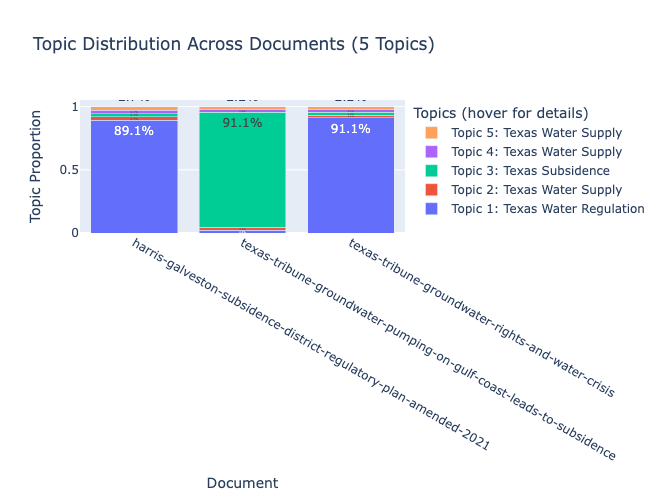

✓ Visualization complete!

Tip: change n_topics above and rerun Step 3a to compare topic structures.


In [12]:
print('Creating topic distribution chart...\n')

topic_df, fig = sbp.plot_topic_distribution(
    doc_topic_dist,
    doc_names,
    topics_info,
    n_topics=n_topics,
)
fig.show()

print('✓ Visualization complete!')
print('\nTip: change n_topics above and rerun Step 3a to compare topic structures.')



### Review the Topic Summary Table

This table gives a compact summary of the discovered topics, including their labels, descriptions, keywords, and average coverage in the corpus.


In [13]:
summary_df = sbp.build_topic_summary(topics_info, doc_topic_dist, top_words_display)
summary_df




,Topic,Label,Description,Top Keywords,Avg Coverage
0,Topic 1,Topic 1: Texas Water Regulation,Texas's regulatory efforts to manage groundwat...,"water, regulatory, groundwater, district, said...",60.8%
1,Topic 2,Topic 2: Texas Water Supply,,"galveston, alternative water, alternative, are...",2.4%
2,Topic 3,Topic 3: Texas Subsidence,Groundwater pumping causes land subsidence in ...,"subsidence, water, said, quot, richmond, body,...",32.0%
3,Topic 4,Topic 4: Texas Water Supply,Documents discussing groundwater management an...,"galveston, alternative water, alternative, are...",2.4%
4,Topic 5,Topic 5: Texas Water Supply,Documents discussing groundwater management an...,"galveston, alternative water, alternative, are...",2.4%


## Step 4: Map to the Science Backbone

This step connects the discovered topics to a scientific domain structure informed by Georgetown CSET's Emerging Technology Observatory (ETO) Map of Science.

**What changes here?**

- The notebook builds topic-specific ETO Map of Science query links
- If you export cluster metadata from ETO list view as CSV, the notebook derives the backbone from that export
- If no export is present, the tutorial falls back to the built-in example backbone

ETO Map of Science is free to use publicly, but ETO's documentation states that the underlying Research Cluster Dataset is not publicly downloadable because of licensing restrictions. In practice, the supported integration path is to use the public Map interface and its list-view CSV export rather than relying on an undocumented raw API.


### Configure Output Names

This cell sets the folder and case-study name used when the notebook writes results to disk. Adjust it if you want to save outputs under a different label.


In [14]:
OUTPUT_DIR = Path('outputs')
OUTPUT_DIR.mkdir(exist_ok=True)
CASE_STUDY_NAME = 'community_analysis'

print(f'✓ Output directory: {OUTPUT_DIR}')
print(f'✓ Case study name: {CASE_STUDY_NAME}')



✓ Output directory: outputs
✓ Case study name: community_analysis


### Build ETO Query Links

This cell turns the discovered topic keywords into ETO Map of Science search URLs. Open the list-view links, refine filters if needed, and export cluster metadata to CSV if you want an ETO-backed backbone.


In [15]:
eto_query_package = sbp.prepare_eto_query_exports(OUTPUT_DIR, topics_info)
ETO_EXPORT_PATH = eto_query_package['eto_export_path']
ETO_QUERY_EXPORT_PATH = eto_query_package['eto_query_export_path']
eto_topic_queries = eto_query_package['eto_topic_queries']

nbutils.print_eto_query_recommendations(eto_topic_queries)
print(f'\nSaved local ETO query recommendations to: {ETO_QUERY_EXPORT_PATH}')
print(f'Expected manual ETO CSV export path: {ETO_EXPORT_PATH}')
print('The notebook does not generate eto_map_export.csv automatically.')
print('Open an ETO list-view URL, export the CSV there, and place it at this path if you want to replace the default backbone.')


## ETO Map of Science Query Recommendations

### Topic 1: Texas Water Regulation
*Texas's regulatory efforts to manage groundwater and prevent subsidence in the Gulf Coast region.*
- **Suggested subjects:** water, regulatory, groundwater
- **List view URL:** `https://sciencemap.eto.tech/?mode=list&all_subjects=water%2C+regulatory%2C+groundwater`
- **Map view URL:** `https://sciencemap.eto.tech/?mode=map&all_subjects=water%2C+regulatory%2C+groundwater`

### Topic 2: Texas Water Supply
- **Suggested subjects:** galveston, alternative water, alternative
- **List view URL:** `https://sciencemap.eto.tech/?mode=list&all_subjects=galveston%2C+alternative+water%2C+alternative`
- **Map view URL:** `https://sciencemap.eto.tech/?mode=map&all_subjects=galveston%2C+alternative+water%2C+alternative`

### Topic 3: Texas Subsidence
*Groundwater pumping causes land subsidence in the Texas Gulf Coast region.*
- **Suggested subjects:** subsidence, water, said
- **List view URL:** `https://sciencemap.eto.tech/?mode=list&all_subjects=subsidence%2C+water%2C+said`
- **Map view URL:** `https://sciencemap.eto.tech/?mode=map&all_subjects=subsidence%2C+water%2C+said`

### Topic 4: Texas Water Supply
*Documents discussing groundwater management and subsidence issues in the Galveston and Harris county areas of Texas.*
- **Suggested subjects:** galveston, alternative water, alternative
- **List view URL:** `https://sciencemap.eto.tech/?mode=list&all_subjects=galveston%2C+alternative+water%2C+alternative`
- **Map view URL:** `https://sciencemap.eto.tech/?mode=map&all_subjects=galveston%2C+alternative+water%2C+alternative`

### Topic 5: Texas Water Supply
*Documents discussing groundwater management and subsidence issues in the Galveston and Harris county areas of Texas.*
- **Suggested subjects:** galveston, alternative water, alternative
- **List view URL:** `https://sciencemap.eto.tech/?mode=list&all_subjects=galveston%2C+alternative+water%2C+alternative`
- **Map view URL:** `https://sciencemap.eto.tech/?mode=map&all_subjects=galveston%2C+alternative+water%2C+alternative`


Saved local ETO query recommendations to: outputs/eto_query_recommendations.csv
Expected manual ETO CSV export path: outputs/eto_map_export.csv
The notebook does not generate eto_map_export.csv automatically.
Open an ETO list-view URL, export the CSV there, and place it at this path if you want to replace the default backbone.


### Load the Science Backbone

If an ETO CSV export is available, the notebook builds the science backbone from the exported cluster disciplines, fields, subfields, and topics, then maps each discovered topic to the closest ETO clusters. Otherwise, it uses the built-in tutorial backbone and keyword-based mapping.


In [16]:
if ETO_EXPORT_PATH.exists():
    eto_clusters_df = sbp.load_eto_cluster_export(ETO_EXPORT_PATH)
    science_backbone = sbp.build_science_backbone_from_eto_export(eto_clusters_df)
    if not science_backbone:
        print("ETO export loaded, but no recognized discipline columns were found. Falling back to the tutorial backbone.")
        science_backbone = sbp.default_science_backbone()
        topic_mappings = sbp.map_topics_to_domains(topics_info)
    else:
        topic_mappings = sbp.map_topics_to_eto_clusters(topics_info, eto_clusters_df)
    print(f"Using ETO export: {ETO_EXPORT_PATH} ({len(eto_clusters_df)} rows)")
else:
    eto_clusters_df = pd.DataFrame()
    science_backbone = sbp.default_science_backbone()
    topic_mappings = sbp.map_topics_to_domains(topics_info)
    print("ETO export not found. Using the tutorial default backbone and heuristic topic mapping.")

nbutils.print_science_backbone(science_backbone)
mapping_df = pd.DataFrame(topic_mappings)
nbutils.print_topic_mappings(topic_mappings)


ETO export not found. Using the tutorial default backbone and heuristic topic mapping.


## Science Backbone

### Water Systems
- Groundwater
- Surface Water
- Hydrology
- Water Management

### Earth and Environmental Change
- Geology
- Geophysics
- Subsidence
- Climate Impacts

### Infrastructure and Operations
- Water Supply Infrastructure
- Monitoring Systems
- Utilities Planning
- Risk Management

### Governance and Decision-Making
- Policy
- Regulation
- Planning
- Stakeholder Engagement

### Society and Economy
- Community Impacts
- Economics
- Public Communication
- Regional Development

### Modeling and Analysis
- Scenario Analysis
- Decision Support
- Data Integration
- Spatial Analysis

## Topic-to-Domain Mappings

### Topic 1: Texas Water Regulation
- **Keywords:** water, regulatory, groundwater, district, said
- **Primary domain:** Water Systems
- **Secondary domain:** Governance and Decision-Making

### Topic 2: Texas Water Supply
- **Keywords:** galveston, alternative water, alternative, areas, water supplies
- **Primary domain:** Water Systems
- **Secondary domain:** Earth and Environmental Change

### Topic 3: Texas Subsidence
- **Keywords:** subsidence, water, said, quot, richmond
- **Primary domain:** Water Systems
- **Secondary domain:** Earth and Environmental Change

### Topic 4: Texas Water Supply
- **Keywords:** galveston, alternative water, alternative, areas, water supplies
- **Primary domain:** Water Systems
- **Secondary domain:** Earth and Environmental Change

### Topic 5: Texas Water Supply
- **Keywords:** galveston, alternative water, alternative, areas, water supplies
- **Primary domain:** Water Systems
- **Secondary domain:** Earth and Environmental Change

### Visualize the Science Backbone Network

This figure places the discovered topics into the science backbone as a simple network. Topic nodes use the human-readable topic labels when those are available, which makes the diagram easier to explain in a tutorial or presentation.


Creating network visualization...



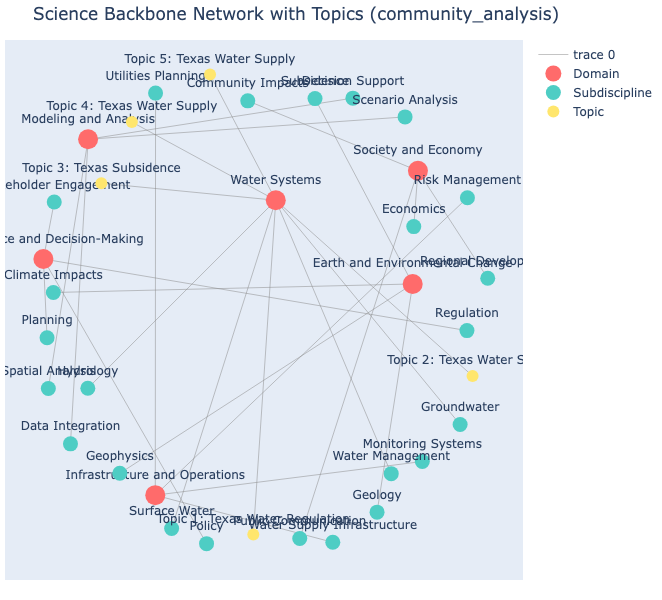

✓ Visualization complete!


In [17]:
print('Creating network visualization...\n')

graph, network_fig = sbp.create_network_figure(
    science_backbone,
    topic_mappings,
    case_study_name=CASE_STUDY_NAME,
)
network_fig.show()

print('✓ Visualization complete!')



## Step 5: Extract Decision Components

Most decision problems include a common set of elements. In this step, the notebook looks for those elements directly in the text.

We focus on:
- Goals: What are we trying to achieve?
- Objectives: Specific, measurable aims
- Decision Variables: What can we control?
- Constraints: Limits that shape what is feasible
- Indicators: How do we measure success?

### Extract Decision Components

This cell searches the corpus for common elements of a decision problem, such as goals, objectives, constraints, and indicators. It provides a first-pass structure for downstream decision analysis.


In [18]:
decision_components = sbp.extract_decision_components(transcripts, nlp)
nbutils.print_decision_components(decision_components)




## Decision Components

### Goals *(10 found)*
1. The Regulatory Plan *[harris-galveston-subsidence-district-regulatory-plan-amended-2021.pdf]*
2. an overall goal *[harris-galveston-subsidence-district-regulatory-plan-amended-2021.pdf]*
3. groundwater withdrawal *[harris-galveston-subsidence-district-regulatory-plan-amended-2021.pdf]*
4. no 
more than 20% *[harris-galveston-subsidence-district-regulatory-plan-amended-2021.pdf]*
5. Regulatory Area *[harris-galveston-subsidence-district-regulatory-plan-amended-2021.pdf]*

### Objectives *(10 found)*
1. The Regulatory Plan *[harris-galveston-subsidence-district-regulatory-plan-amended-2021.pdf]*
2. an overall goal *[harris-galveston-subsidence-district-regulatory-plan-amended-2021.pdf]*
3. groundwater withdrawal *[harris-galveston-subsidence-district-regulatory-plan-amended-2021.pdf]*
4. no 
more than 20% *[harris-galveston-subsidence-district-regulatory-plan-amended-2021.pdf]*
5. Regulatory Area *[harris-galveston-subsidence-district-regulatory-plan-amended-2021.pdf]*

### Variables *(10 found)*
1. a permit *[harris-galveston-subsidence-district-regulatory-plan-amended-2021.pdf]*
2. groundwater withdrawals *[harris-galveston-subsidence-district-regulatory-plan-amended-2021.pdf]*
3. the District *[harris-galveston-subsidence-district-regulatory-plan-amended-2021.pdf]*
4. the public benefit *[harris-galveston-subsidence-district-regulatory-plan-amended-2021.pdf]*
5. individual hardship *[harris-galveston-subsidence-district-regulatory-plan-amended-2021.pdf]*

### Constraints *(10 found)*
1. The District *[harris-galveston-subsidence-district-regulatory-plan-amended-2021.pdf]*
2. groundwater withdrawals *[harris-galveston-subsidence-district-regulatory-plan-amended-2021.pdf]*
3. the guidelines *[harris-galveston-subsidence-district-regulatory-plan-amended-2021.pdf]*
4. the District Act *[harris-galveston-subsidence-district-regulatory-plan-amended-2021.pdf]*
5. this Regulatory Plan *[harris-galveston-subsidence-district-regulatory-plan-amended-2021.pdf]*

### Indicators *(10 found)*
1. the areas *[harris-galveston-subsidence-district-regulatory-plan-amended-2021.pdf]*
2. tidal storm surges *[harris-galveston-subsidence-district-regulatory-plan-amended-2021.pdf]*
3. fault 
movement *[harris-galveston-subsidence-district-regulatory-plan-amended-2021.pdf]*
4. a permit *[harris-galveston-subsidence-district-regulatory-plan-amended-2021.pdf]*
5. groundwater withdrawals *[harris-galveston-subsidence-district-regulatory-plan-amended-2021.pdf]*

### Compare Decision Component Counts

This bar chart summarizes how many items were found for each decision-component type. It helps you see which parts of the decision framing are well represented in the text.


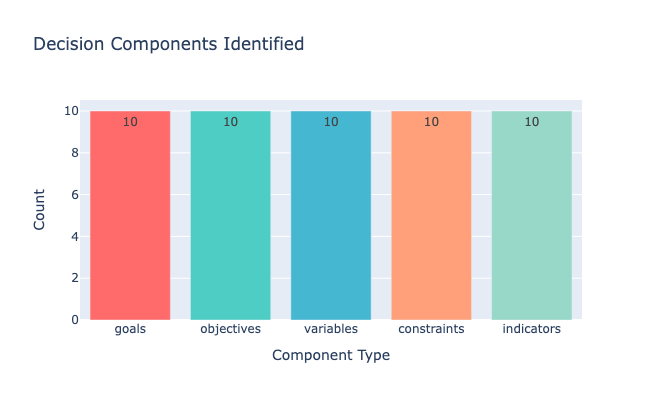

✓ Visualization complete!


In [19]:
component_counts_map = sbp.component_counts(decision_components)
component_fig = sbp.plot_component_distribution(component_counts_map)
component_fig.show()

print('✓ Visualization complete!')



### Build a Reusable Decision-Component Table

This cell turns the extracted decision components into a tabular structure that can be filtered, exported, or reused later in the notebook.


In [20]:
components_df = sbp.component_table(decision_components)
components_df




,component_type,text,source,context
0,goals,The Regulatory Plan,harris-galveston-subsidence-district-regulator...,The Regulatory Plan was developed with an over...
1,goals,an overall goal,harris-galveston-subsidence-district-regulator...,The Regulatory Plan was developed with an over...
2,goals,groundwater withdrawal,harris-galveston-subsidence-district-regulator...,The Regulatory Plan was developed with an over...
3,goals,no \nmore than 20%,harris-galveston-subsidence-district-regulator...,The Regulatory Plan was developed with an over...
4,goals,Regulatory Area,harris-galveston-subsidence-district-regulator...,The Regulatory Plan was developed with an over...
5,goals,total water demand,harris-galveston-subsidence-district-regulator...,The Regulatory Plan was developed with an over...
6,goals,the objectives,harris-galveston-subsidence-district-regulator...,To achieve the objectives for each Regulatory ...
7,goals,each Regulatory Area,harris-galveston-subsidence-district-regulator...,To achieve the objectives for each Regulatory ...
8,goals,the District,harris-galveston-subsidence-district-regulator...,To achieve the objectives for each Regulatory ...
9,goals,groundwater withdrawals,harris-galveston-subsidence-district-regulator...,To achieve the objectives for each Regulatory ...


## Step 6: Link to Scientific Variables

**What are Scientific Variable Objects (SVOs)?**

An SVO is a standardized description of a measurable quantity.

It helps translate everyday language into scientific variables that can be observed, modeled, or retrieved from data systems.

In this tutorial, the scientific-variable vocabulary now comes from the MINT variable presentations API when available, with a small local fallback vocabulary for offline use.

Each SVO-style entry can include:
- Variable Name: What we measure
- Units: How we measure it
- Data Source: Where the variable definition came from
- Standard Name: Scientific terminology
- Domain: A broad scientific grouping when available

This step creates a translation layer between stakeholder language and measurable scientific concepts.



### Load the Scientific-Variable Vocabulary

This cell retrieves scientific variable definitions from the MINT API when available. If the live service is unavailable, it falls back to a smaller local tutorial vocabulary so the workflow can continue.


In [21]:
USE_MINT_SVO_VOCABULARY = True
MINT_SVO_API_BASE_URL = MINT_API_BASE_URL
MINT_SVO_USERNAME = MINT_USERNAME

try:
    if USE_MINT_SVO_VOCABULARY:
        svo_vocabulary = sbp.fetch_mint_svo_vocabulary(
            base_url=MINT_SVO_API_BASE_URL,
            username=MINT_SVO_USERNAME,
            per_page=MINT_SVO_PER_PAGE,
            max_pages=MINT_SVO_MAX_PAGES,
        )
        svo_source = 'MINT variablepresentations API'
    else:
        raise RuntimeError('Configured to use local fallback vocabulary.')
except Exception as exc:
    print(f'Falling back to local demo SVO vocabulary: {exc}')
    svo_vocabulary = sbp.default_svo_vocabulary()
    svo_source = 'Local fallback vocabulary'

nbutils.print_svo_vocabulary_preview(svo_vocabulary, svo_source)


**SVO vocabulary source:** MINT variablepresentations API
**Variables available:** 323

### `crop_id`
- **Label:** crop id
- **Standard:** crop-or-weed species identification code
- **Units:** code
- **Domain:** Agriculture

### `soil_drained_upper_limit`
- **Label:** soil drained upper limit
- **Standard:** soil drained water upper limit of volume fraction
- **Units:** cm3 cm-3
- **Domain:** Soil Science

### `saturated_hydraulic_conductivity`
- **Label:** Saturated hydraulic conductivity
- **Standard:** soil water saturated hydraulic conductivity
- **Units:** cm h-1
- **Domain:** Soil Science

### `actual_tr`
- **Label:** Actual Tr
- **Standard:** crop water time integral of transpiration volume flux
- **Units:** mm
- **Domain:** Soil Science

### `ag_biomass`
- **Label:** Ag Biomass
- **Standard:** ground above crop biomass dry mass-per-area density
- **Units:** Mg ha-1
- **Domain:** Agriculture

### `ag_n`
- **Label:** Ag N
- **Standard:** ground above crop nitrogen mass-per-area density
- **Units:** kg ha-1
- **Domain:** Agriculture

### `ag_n_concn`
- **Label:** Ag N Concn
- **Standard:** ground above crop nitrogen mass fraction
- **Units:** g kg-1
- **Domain:** Agriculture

### `ag_residue`
- **Label:** Ag Residue
- **Standard:** ground above residue remaining at-harvest mass-per-area density
- **Units:** Mg ha-1
- **Domain:** Agriculture

### `avg_gross_n_min`
- **Label:** Avg Gross N Min
- **Standard:** nitrogen average of gross mass mineralization rate
- **Units:** kg/yr
- **Domain:** General Science

### `avg_n2o_fr_deni`
- **Label:** Avg N2O Fr Deni
- **Standard:** soil nitrous-oxide-as-nitrogen average of denitrification mass emission rate
- **Units:** kg/yr
- **Domain:** Soil Science

### SVO Matching Options

Use these controls to tighten or loosen how natural-language terms are matched to scientific variables.

- `SVO_MIN_KEYWORD_WORDS` sets the minimum number of words required for an automatic match.
- `SVO_SINGLE_WORD_ALLOWLIST` lets you preserve a small set of strong scientific one-word terms.


### Control How Strictly SVOs Are Matched

Use these settings to decide how cautious the notebook should be when linking natural-language terms to scientific variables. Stricter settings reduce false positives; looser settings can recover more matches.


In [22]:
SVO_MIN_KEYWORD_WORDS = 2
SVO_SINGLE_WORD_ALLOWLIST = {
    'subsidence',
    'precipitation',
    'salinity',
    'groundwater',
}

print(f'Minimum keyword length: {SVO_MIN_KEYWORD_WORDS} words')
print(f'Allowed single-word scientific terms: {sorted(SVO_SINGLE_WORD_ALLOWLIST)}')



Minimum keyword length: 2 words
Allowed single-word scientific terms: ['groundwater', 'precipitation', 'salinity', 'subsidence']


### Link Narrative Terms to Scientific Variables

This cell matches terms from the corpus to scientific variables in the vocabulary. The result is a bridge between everyday language and measurable scientific concepts.


In [23]:
svo_mappings = sbp.create_svo_mappings(
    transcripts,
    svo_vocabulary,
    min_keyword_words=SVO_MIN_KEYWORD_WORDS,
    allow_single_word_keywords=SVO_SINGLE_WORD_ALLOWLIST,
)
unique_mappings = sbp.deduplicate_svo_mappings(svo_mappings)
svo_df = sbp.svo_table(unique_mappings)
nbutils.print_svo_mapping_summary(unique_mappings)




**Semantic links created:** 25

### 1. *'groundwater'* -> `constant_head`
- **Standard:** groundwater constant head
- **Units:** m
- **Domain:** Hydrology
- **Data source:** MINT variablepresentations API

### 2. *'groundwater'* -> `groundwater_head`
- **Standard:** groundwater head
- **Units:** m
- **Domain:** Hydrology
- **Data source:** MINT variablepresentations API

### 3. *'surface water'* -> `surface_water`
- **Standard:** land surface water depth
- **Units:** m
- **Domain:** Hydrology
- **Data source:** MINT variablepresentations API

### 4. *'groundwater'* -> `ground_water_well_flow_rate`
- **Standard:** groundwater well volume flow rate
- **Units:** unknown
- **Domain:** Hydrology
- **Data source:** MINT variablepresentations API

### 5. *'groundwater'* -> `groundwater_well_recharge_volume_flux`
- **Standard:** groundwater well recharge volume flux
- **Units:** m/h
- **Domain:** Hydrology
- **Data source:** MINT variablepresentations API

### 6. *'groundwater'* -> `groundwater_recharge_volume_flux`
- **Standard:** groundwater recharge volume flux
- **Units:** unknown
- **Domain:** Hydrology
- **Data source:** MINT variablepresentations API

### Optional MINT Queries for Each Topic

This optional step uses the MINT catalog to suggest which scientific domains and tags are worth querying next for each topic.


### Recommend MINT Models for Matched Variables

This optional cell suggests MINT models or model configurations that appear relevant to the scientific variables found in the corpus. Treat these as candidate starting points for further review.


In [24]:
USE_MINT_MODEL_RECOMMENDATIONS = True
MINT_MODEL_API_BASE_URL = MINT_API_BASE_URL
MINT_MODEL_USERNAME = MINT_USERNAME
MINT_MODELS_PER_SVO = 2

model_recommendations = []
model_recommendations_df = pd.DataFrame()

if USE_MINT_MODEL_RECOMMENDATIONS and unique_mappings:
    try:
        mint_model_candidates = sbp.fetch_mint_model_candidates(
            base_url=MINT_MODEL_API_BASE_URL,
            username=MINT_MODEL_USERNAME,
            per_page=MINT_MODEL_PER_PAGE,
            max_pages=MINT_MODEL_MAX_PAGES,
        )
        model_recommendations = sbp.recommend_models_for_svo_mappings(
            unique_mappings,
            mint_model_candidates,
            recommendations_per_svo=MINT_MODELS_PER_SVO,
        )
        model_recommendations_df = pd.DataFrame(model_recommendations)
        nbutils.print_svo_model_recommendations(model_recommendations_df)
    except Exception as exc:
        print(f'Could not retrieve MINT model recommendations: {exc}')
else:
    print('Skipping MINT model recommendations.')


**SVO-to-model recommendations:** 50

### `anistropy`
- **1.** GAMACTT: Groundwater age mixtures and contaminant trend tools *[Model]*
  Categories: Hydrology
  Why: The webtool is based on the concept of groundwater stratigraphy whereby changes in contaminant concentrations in recharge may be recorded as a vertical concentration gradient in th
- **2.** BCM: Basin Characterization Model *[Model]*
  Categories: Hydrology
  Why: The Basin Characterization Model (BCM) is a mathematical computer model that calculates the hydrologic inputs and outputs of a specific landscape area and is generally run at a mon

### `conductance`
- **1.** MODPATH Observation Process *[Model]*
  Categories: Hydrology
  Why: The MODPATH-OBS (Hanson and others, 2013) computer program is designed to calculate simulated equivalents for observations related to advective groundwater transport that can be re
- **2.** Central Valley Hydrologic Model *[Model Configuration]*
  Categories: Hydrology
  Why: CVHM Components 1. Geospatial Database A Geographic Information System (GIS) was used to compile, manage, store, and analyze the large quantities of data in the geospatial database

### `constant_head`
- **1.** MODFLOW 2005 configuration *[Model Configuration]*
  Categories: Hydrology
  Why: MODFLOW 2005 configuration using variable recharge files
- **2.** MODPATH Observation Process *[Model]*
  Categories: Hydrology
  Why: The MODPATH-OBS (Hanson and others, 2013) computer program is designed to calculate simulated equivalents for observations related to advective groundwater transport that can be re

### `drawdown`
- **1.** CRT: Cascade routing tool to define and visualize flow paths for grid-based watershed model *[Model]*
  Categories: Hydrology
  Why: The U.S. Geological Survey Cascade Routing Tool (CRT) is a computer application for watershed models that include the coupled Groundwater and Surface-water FLOW model GSFLOW and th
- **2.** BCM: Basin Characterization Model *[Model]*
  Categories: Hydrology
  Why: The Basin Characterization Model (BCM) is a mathematical computer model that calculates the hydrologic inputs and outputs of a specific landscape area and is generally run at a mon

### `flow_front_face`
- **1.** MODPATH Observation Process *[Model]*
  Categories: Hydrology
  Why: The MODPATH-OBS (Hanson and others, 2013) computer program is designed to calculate simulated equivalents for observations related to advective groundwater transport that can be re
- **2.** BCM: Basin Characterization Model *[Model]*
  Categories: Hydrology
  Why: The Basin Characterization Model (BCM) is a mathematical computer model that calculates the hydrologic inputs and outputs of a specific landscape area and is generally run at a mon

### `ground_water_well_flow_rate`
- **1.** MODPATH Observation Process *[Model]*
  Categories: Hydrology
  Why: The MODPATH-OBS (Hanson and others, 2013) computer program is designed to calculate simulated equivalents for observations related to advective groundwater transport that can be re
- **2.** GAMACTT: Groundwater age mixtures and contaminant trend tools *[Model]*
  Categories: Hydrology
  Why: The webtool is based on the concept of groundwater stratigraphy whereby changes in contaminant concentrations in recharge may be recorded as a vertical concentration gradient in th

### `groundwater_head`
- **1.** MODFLOW 2005 configuration *[Model Configuration]*
  Categories: Hydrology
  Why: MODFLOW 2005 configuration using variable recharge files
- **2.** MODPATH Observation Process *[Model]*
  Categories: Hydrology
  Why: The MODPATH-OBS (Hanson and others, 2013) computer program is designed to calculate simulated equivalents for observations related to advective groundwater transport that can be re

### `groundwater_recharge_volume_flux`
- **1.** BCM: Basin Characterization Model *[Model]*
  Categories: Hydrology
  Why: The Basin Characterization Model (BCM) is a mathematical computer model that calculates the hydrologic inputs and outputs of a specific landscape area and is generally run at a mon
- **2.** GAMACTT: Groundwater age mixtures and contaminant trend tools *[Model]*
  Categories: Hydrology
  Why: The webtool is based on the concept of groundwater stratigraphy whereby changes in contaminant concentrations in recharge may be recorded as a vertical concentration gradient in th

### `groundwater_well_recharge_volume_flux`
- **1.** GAMACTT: Groundwater age mixtures and contaminant trend tools *[Model]*
  Categories: Hydrology
  Why: The webtool is based on the concept of groundwater stratigraphy whereby changes in contaminant concentrations in recharge may be recorded as a vertical concentration gradient in th
- **2.** MODFLOW 2005 configuration *[Model Configuration]*
  Categories: Hydrology
  Why: MODFLOW 2005 configuration using variable recharge files

### `head`
- **1.** MODFLOW 2005 configuration *[Model Configuration]*
  Categories: Hydrology
  Why: MODFLOW 2005 configuration using variable recharge files
- **2.** MODPATH Observation Process *[Model]*
  Categories: Hydrology
  Why: The MODPATH-OBS (Hanson and others, 2013) computer program is designed to calculate simulated equivalents for observations related to advective groundwater transport that can be re

### `horizontal_hydraulic_conductivity`
- **1.** Central Valley Hydrologic Model *[Model Configuration]*
  Categories: Hydrology
  Why: CVHM Components 1. Geospatial Database A Geographic Information System (GIS) was used to compile, manage, store, and analyze the large quantities of data in the geospatial database
- **2.** MODPATH Observation Process *[Model]*
  Categories: Hydrology
  Why: The MODPATH-OBS (Hanson and others, 2013) computer program is designed to calculate simulated equivalents for observations related to advective groundwater transport that can be re

### `precipitation`
- **1.** BCM: Basin Characterization Model *[Model]*
  Categories: Hydrology
  Why: The Basin Characterization Model (BCM) is a mathematical computer model that calculates the hydrologic inputs and outputs of a specific landscape area and is generally run at a mon
- **2.** TopoFlow *[Model]*
  Categories: Hydrology
  Why: Topoflow is a powerful spatially-distributed hydrologic model for various physical processes in a watershed, with the goal of accurately predicting how various hydrologic variables

### `q`
- **1.** GAMACTT: Groundwater age mixtures and contaminant trend tools *[Model]*
  Categories: Hydrology
  Why: The webtool is based on the concept of groundwater stratigraphy whereby changes in contaminant concentrations in recharge may be recorded as a vertical concentration gradient in th
- **2.** MODPATH Observation Process *[Model]*
  Categories: Hydrology
  Why: The MODPATH-OBS (Hanson and others, 2013) computer program is designed to calculate simulated equivalents for observations related to advective groundwater transport that can be re

### `recharge`
- **1.** BCM: Basin Characterization Model *[Model]*
  Categories: Hydrology
  Why: The Basin Characterization Model (BCM) is a mathematical computer model that calculates the hydrologic inputs and outputs of a specific landscape area and is generally run at a mon
- **2.** GAMACTT: Groundwater age mixtures and contaminant trend tools *[Model]*
  Categories: Hydrology
  Why: The webtool is based on the concept of groundwater stratigraphy whereby changes in contaminant concentrations in recharge may be recorded as a vertical concentration gradient in th

### `standard_precipitation_index`
- **1.** Drought Indices Model *[Model]*
  Categories: Weather
  Why: The Drought Indices Model (SDI) uses data from several climate sources (CHIRPS, GLDAS, FLDAS, and ECMWF) to generate three useful climate indices: the Standardized Precipitation In
- **2.** DroughtPredict *[Model]*
  Categories: Weather
  Why: DoughtPredict uses deep learning to make predictions of SPI on a variety of timescales. 

See the specific version and configuration for information on the deep learning model stru

### `start`
- **1.** MODPATH Observation Process *[Model]*
  Categories: Hydrology
  Why: The MODPATH-OBS (Hanson and others, 2013) computer program is designed to calculate simulated equivalents for observations related to advective groundwater transport that can be re
- **2.** MODFLOW 2005 configuration *[Model Configuration]*
  Categories: Hydrology
  Why: MODFLOW 2005 configuration using variable recharge files

### `storage_coefficient_1`
- **1.** TracerLPM *[Model]*
  Categories: Hydrology
  Why: Lumped parameter models are mathematical models of transport based on simplified aquifer geometry and flow configurations that account for effects of hydrodynamic dispersion or mix
- **2.** BCM: Basin Characterization Model *[Model]*
  Categories: Hydrology
  Why: The Basin Characterization Model (BCM) is a mathematical computer model that calculates the hydrologic inputs and outputs of a specific landscape area and is generally run at a mon

### `storage_coefficient_2`
- **1.** BCM: Basin Characterization Model *[Model]*
  Categories: Hydrology
  Why: The Basin Characterization Model (BCM) is a mathematical computer model that calculates the hydrologic inputs and outputs of a specific landscape area and is generally run at a mon
- **2.** CRT: Cascade routing tool to define and visualize flow paths for grid-based watershed model *[Model]*
  Categories: Hydrology
  Why: The U.S. Geological Survey Cascade Routing Tool (CRT) is a computer application for watershed models that include the coupled Groundwater and Surface-water FLOW model GSFLOW and th

### `subsidence`
- **1.** Texas Coastal Modeling & Subsidence *[Model Configuration]*
  Categories: Decision_Support
  Why: This configuration allows users in the subsidence and oil spill modeling research for the state of Texas to complete transcriptions within the DYNAMO suite of services and enables 
- **2.** BCM: Basin Characterization Model *[Model]*
  Categories: Hydrology
  Why: The Basin Characterization Model (BCM) is a mathematical computer model that calculates the hydrologic inputs and outputs of a specific landscape area and is generally run at a mon

### `surface_water`
- **1.** BCM: Basin Characterization Model *[Model]*
  Categories: Hydrology
  Why: The Basin Characterization Model (BCM) is a mathematical computer model that calculates the hydrologic inputs and outputs of a specific landscape area and is generally run at a mon
- **2.** GHOST: A watershed-scale hydrologic model *[Model]*
  Categories: Hydrology
  Why: IWA researchers at IIHRâ€”Hydroscience & Engineering (the parent organization of the Iowa Flood Center) developed and implemented a watershed-scale hydrologic model, the Generic Hy

### `total_precipitation_rate`
- **1.** Cycles configuration (v0.10.2) for grouped weather-soil files and exposing weed fraction and fertilizer rate *[Model Configuration]*
  Categories: Agriculture
  Why: Cycles configuration (version 0.10.2) for grouped weather and soil files and exposing additional parameters such as weeds fraction and fertilizer rate
- **2.** Cycles configuration (v0.9.3) *[Model Configuration]*
  Categories: Agriculture
  Why: Cycles (version 0.9.3) simple configuration

### `transmissivity`
- **1.** BCM: Basin Characterization Model *[Model]*
  Categories: Hydrology
  Why: The Basin Characterization Model (BCM) is a mathematical computer model that calculates the hydrologic inputs and outputs of a specific landscape area and is generally run at a mon
- **2.** CRT: Cascade routing tool to define and visualize flow paths for grid-based watershed model *[Model]*
  Categories: Hydrology
  Why: The U.S. Geological Survey Cascade Routing Tool (CRT) is a computer application for watershed models that include the coupled Groundwater and Surface-water FLOW model GSFLOW and th

### `vertical_hydraulic_conductivity`
- **1.** Central Valley Hydrologic Model *[Model Configuration]*
  Categories: Hydrology
  Why: CVHM Components 1. Geospatial Database A Geographic Information System (GIS) was used to compile, manage, store, and analyze the large quantities of data in the geospatial database
- **2.** GAMACTT: Groundwater age mixtures and contaminant trend tools *[Model]*
  Categories: Hydrology
  Why: The webtool is based on the concept of groundwater stratigraphy whereby changes in contaminant concentrations in recharge may be recorded as a vertical concentration gradient in th

### `z_displacement`
- **1.** BCM: Basin Characterization Model *[Model]*
  Categories: Hydrology
  Why: The Basin Characterization Model (BCM) is a mathematical computer model that calculates the hydrologic inputs and outputs of a specific landscape area and is generally run at a mon
- **2.** CRT: Cascade routing tool to define and visualize flow paths for grid-based watershed model *[Model]*
  Categories: Hydrology
  Why: The U.S. Geological Survey Cascade Routing Tool (CRT) is a computer application for watershed models that include the coupled Groundwater and Surface-water FLOW model GSFLOW and th

### `zone_file`
- **1.** GAMACTT: Groundwater age mixtures and contaminant trend tools *[Model]*
  Categories: Hydrology
  Why: The webtool is based on the concept of groundwater stratigraphy whereby changes in contaminant concentrations in recharge may be recorded as a vertical concentration gradient in th
- **2.** TracerLPM *[Model]*
  Categories: Hydrology
  Why: Lumped parameter models are mathematical models of transport based on simplified aquifer geometry and flow configurations that account for effects of hydrodynamic dispersion or mix

### Visualize Scientific Variables by Domain

This chart summarizes which scientific domains are represented by the matched variables. It gives a quick sense of where the narrative is strongest in scientific terms.


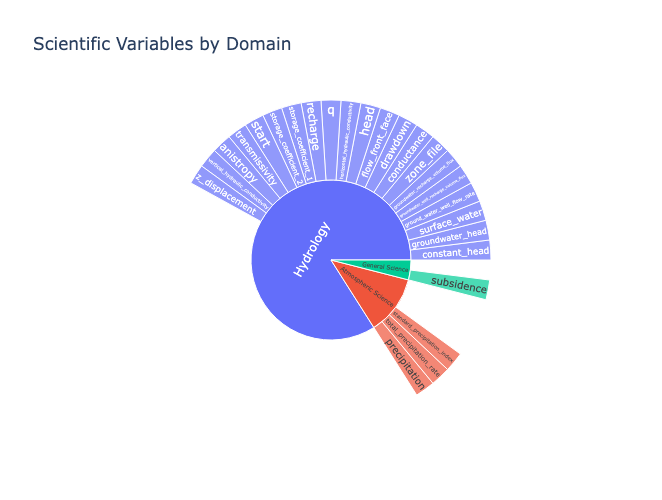

**Domains covered:** 3
- **Hydrology:** 21
- **Atmospheric Science:** 3
- **General Science:** 1

In [25]:
_, sunburst_fig, domain_counts = sbp.plot_svo_sunburst(unique_mappings)
sunburst_fig.show()
nbutils.print_domain_counts(domain_counts)




## Interpreting the Sunburst Figure

The **Scientific Variables by Domain** sunburst chart shows how stakeholder narratives connect to scientific concepts.

### What the figure shows

**Inner ring:** scientific domains such as Hydrology, Climate Science, Social Science, Economics, Engineering, and Oceanography

**Outer ring:** individual scientific variables nested within each domain, such as:
- `water_level` and `groundwater_level` under Hydrology
- `precipitation` under Climate Science  
- `economic_damage` under Economics
- `infrastructure_vulnerability` under Engineering

**Segment size:** proportional to how frequently each domain or variable appears in the mapped text

### What it tells you

1. **Problem scope:** which scientific disciplines are most relevant to the stakeholder concerns

2. **Data needs:** what kinds of measurements, datasets, or monitoring systems may support the decision process

3. **Interdisciplinary structure:** whether the problem is concentrated in one field or spread across several domains

4. **Stakeholder priorities:** which measurable concepts best reflect the language people use to describe the problem

### Why this matters for TACC workflows

This figure helps you identify:
- Which computational models you need (hydrological, economic, infrastructure assessment)
- What datasets to access from TACC resources or external sources
- Which scientific experts should be engaged
- How to structure your decision support system to match stakeholder mental models

In short, it shows which science is needed to answer the questions the community is asking.

## Step 7: Generate Summary Report

In the final step, the notebook writes a short report that summarizes the topics, mappings, decision components, and generated outputs.

### Export the Results

This cell writes the key outputs of the analysis to disk, including tables, figures, and a summary report. It is the main checkpoint for saving the notebook results.


In [26]:
output_files = sbp.write_outputs_table(
    OUTPUT_DIR,
    CASE_STUDY_NAME,
    topic_mappings,
    components_df,
    svo_df,
    network_fig,
    sunburst_fig,
)

summary = sbp.build_summary_report(
    CASE_STUDY_NAME,
    transcripts,
    n_topics,
    topic_mappings,
    decision_components,
    unique_mappings,
    svo_df,
)
report_path = sbp.write_report(OUTPUT_DIR, CASE_STUDY_NAME, summary)
nbutils.print_export_summary(
    transcripts,
    n_topics,
    topic_mappings,
    decision_components,
    unique_mappings,
    output_files,
    report_path,
)




## Semantic Bridge Analysis Complete
- **Documents analyzed:** 3
- **Topics identified:** 5
- **Scientific domains:** 1
- **Decision components:** 50
- **Scientific variables:** 25
- **Output files:**
  - `community_analysis_topic_mappings.csv`
  - `community_analysis_components.csv`
  - `community_analysis_svo_mappings.csv`
  - `community_analysis_network.html`
  - `community_analysis_svo_sunburst.html`
  - `community_analysis_report.md`

### Preview the Summary Report

Use this cell to inspect the beginning of the generated report before sharing it or moving it into another workflow.


In [27]:
nbutils.print_report_preview(summary, report_path)




## Report Preview
```text
# Semantic Bridge Analysis Report

## community_analysis

**Generated:** 2026-04-17 11:23

---

## Analysis Summary

- **Documents Analyzed:** 3
- **Topics Identified:** 5
- **Scientific Domains:** 1
- **Decision Components:** 50
- **Scientific Variables:** 25

---

## Key Findings

### Topics Discovered

**Topic 1**
- Keywords: water, regulatory, groundwater, district, said
- Primary Domain: Water Systems
- Secondary Domain: Governance and Decision-Making

**Topic 2**
- Keywords: galveston, alternative water, alternative, areas, water supplies
- Primary Domain: Water Systems
- Secondary Domain: Earth and Environmental Change

**Topic 3**
- Keywords: subsidence, water, said, quot, richmond
- Primary Domain: Water Systems
- Secondary Domain: Earth and Environmental Change

**Topic 4**
- Keywords: galveston, alternative water, alternative, areas, water supplies
- Primary Domain: Water Systems
- Secondary Domain: Earth and Environmental Change

**Topic 5**
- Keywords: galveston, alternati
...
```
**Full report:** `outputs/community_analysis_report.md`

### Create a Quick Reference Table

This final table condenses the major outputs of the workflow into a single summary view. It can be useful for presentations, handoffs, or rapid review.


In [28]:
quick_ref = sbp.build_quick_reference(
    transcripts,
    n_topics,
    topic_mappings,
    decision_components,
    svo_vocabulary,
    unique_mappings,
    output_files,
)

quick_ref_path = OUTPUT_DIR / f'{CASE_STUDY_NAME}_summary_table.csv'
quick_ref.to_csv(quick_ref_path, index=False)
quick_ref




,Analysis Component,Count,Output File
0,Input Documents,3,N/A
1,Topics Discovered,5,community_analysis_topic_mappings.csv
2,Scientific Domains,1,community_analysis_network.html
3,Decision Components,50,community_analysis_components.csv
4,Scientific Variables,323,community_analysis_svo_mappings.csv
5,Semantic Links,25,community_analysis_svo_mappings.csv


## Wrap-Up

You have completed the semantic bridge analysis workflow.

### What you learned
- How to extract topics from text automatically
- How to map narratives to scientific domains
- How to identify decision components
- How to link language to measurable variables

### How to apply this to your own work
1. Replace sample data with your own documents
2. Customize domains in `science_backbone`
3. Expand `svo_vocabulary`
4. Adjust the `n_topics` parameter
5. Re-run and validate with stakeholders

### Output files
All results are saved in the `outputs/` folder:
- CSV files for further analysis
- HTML visualizations for sharing
- Markdown report for documentation

### Next steps
- Review the generated outputs with domain experts and stakeholders
- Refine the science backbone and variable mappings for your domain
- Connect the results to downstream datasets, models, or decision tools

This workflow is designed to preserve stakeholder language while connecting it to scientific and engineering analysis.